# Taller 6: Morfología matemática

## Cargue y visualice la imagen amour.png.

In [2]:
PATH = './imagenes/'

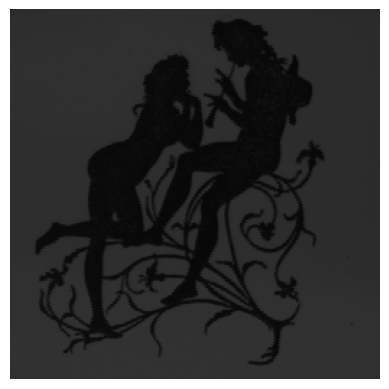

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen_amour = cv2.imread(PATH + 'AMOUR.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(imagen_amour, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

## Realice la operación de apertura usando una máscara cuadrada de tamaño 5x5. ¿Qué partes fueron suprimidas? Nota: No es lo mismo aplicar dos veces seguidas la operación de apertura con una máscara de 3x3 que una sola vez con una máscara de 5x5. Hacer una segunda apertura no sirve de nada (no produce ningún efecto) ya que la operación de apertura es idempotente, es decir: apertura(apertura(imagen, máscara)) = apertura(imagen, máscara).

Creamos un elemento estructurante rectangular de tamaño 5x5 y aplicamos la operación de apertura a la imagen. 

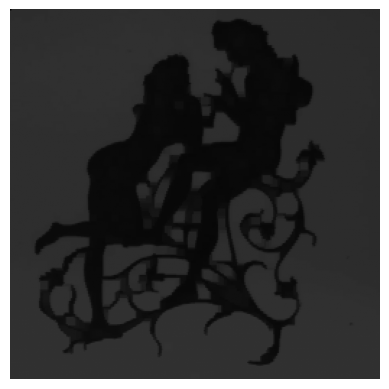

In [ ]:
from skimage.morphology import opening, closing, footprint_rectangle

fp = footprint_rectangle((5, 5))

imagen_amour_opened = opening(imagen_amour, fp)
plt.imshow(imagen_amour_opened, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

Se perdieron los elementos más pequeños que el tamaño del elemento estructurante (5x5 píxeles). Esto incluye detalles y conexiones delgadas.

## Retome la imagen original, y aplique una umbralización para binarizarla (umbral = 35).

Aplicamos la umbralización para binarizar la imagen y luego la visualizamos.

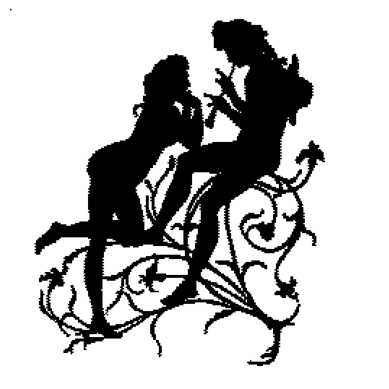

In [8]:
thres_value, thres_image = cv2.threshold(imagen_amour, 35, 255, cv2.THRESH_BINARY)
plt.imshow(thres_image, cmap='gray')
plt.axis('off')
plt.show()

## Realice el cierre de la imagen. Para esto, efectúe 4 cierres aplicando sucesivamente las 4 máscaras lineales simétricas de tamaño 1x3 (en este orden: las dos diagonales ( / y después \ ), horizontal ( - ) y vertical ( | )). 

- Las máscaras diagonales (u oblicuas) deben crearse generando una matriz de 3x3 y colocando 1’ s sobre las diagonales. Los demás elementos se deben dejar vacíos (SIN CEROS).

- La máscara horizontal debe crearse generando una matriz de 3x1 llena de 1’s.

- La máscara vertical debe crearse generando una matriz de 1x3 llena de 1’s.

In [11]:
from skimage.morphology import closing
import numpy as np

mascara_diag1 = np.array([[0, 0, 1],
                          [0, 1, 0],
                          [1, 0, 0]], dtype=bool)

print("Máscara diagonal:")
print(mascara_diag1.astype(int))

mascara_diag2 = np.array([[1, 0, 0],
                          [0, 1, 0],
                          [0, 0, 1]], dtype=bool)

print("\nMáscara diagonal:")
print(mascara_diag2.astype(int))


mascara_horizontal = np.ones((1, 3), dtype=bool)

print("\nMáscara horizontal:")
print(mascara_horizontal.astype(int))


mascara_vertical = np.ones((3, 1), dtype=bool)

print("\nMáscara vertical:")
print(mascara_vertical.astype(int))

Máscara diagonal:
[[0 0 1]
 [0 1 0]
 [1 0 0]]

Máscara diagonal:
[[1 0 0]
 [0 1 0]
 [0 0 1]]

Máscara horizontal:
[[1 1 1]]

Máscara vertical:
[[1]
 [1]
 [1]]


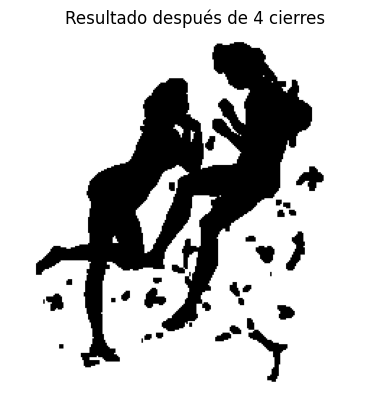

In [14]:
imagen_resultado = thres_image.copy()
imagen_resultado = closing(imagen_resultado, mascara_diag1)
imagen_resultado = closing(imagen_resultado, mascara_diag2)
imagen_resultado = closing(imagen_resultado, mascara_horizontal)
imagen_resultado = closing(imagen_resultado, mascara_vertical)

plt.imshow(imagen_resultado, cmap='gray')
plt.title('Resultado después de 4 cierres')
plt.axis('off')
plt.show()

## ¿Cuál es el efecto obtenido?

Vemos los siguientes efectos:

- Las líneas de la parte inferior casi desaparecieron.
- Se pierden detalles pequeños en las figuras humanas.


## Tome el negativo de la imagen resultado, de forma tal que las figuras se vuelvan blancas.

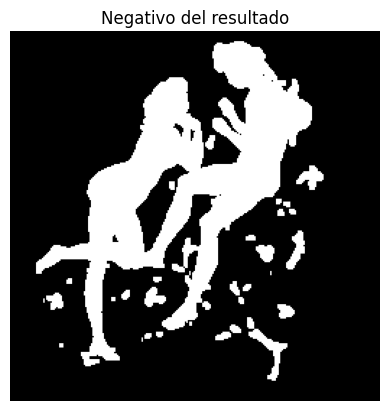

In [16]:
imagen_negativa = cv2.bitwise_not(imagen_resultado)

plt.imshow(imagen_negativa, cmap='gray')
plt.title('Negativo del resultado')
plt.axis('off')
plt.show()

## Seleccione el componente conexo más grande. ¿Cuál es el resultado?

Número de componentes conectados: 31


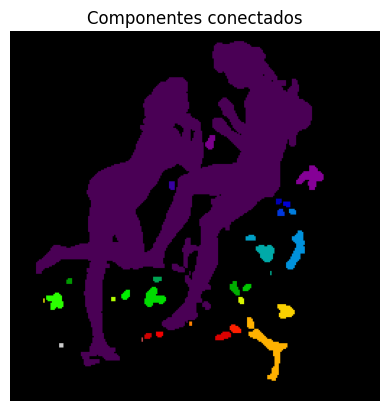

In [17]:
from skimage.measure import label

connected_components = label(imagen_negativa, background=0, connectivity=2)
num_componentes = connected_components.max()
print(f"Número de componentes conectados: {num_componentes}")
plt.imshow(connected_components, cmap='nipy_spectral')
plt.title('Componentes conectados')
plt.axis('off')
plt.show()

El componente conexo más grande es el que vemos en color púrpura más oscuro. Podemos ver que incluye las figuras humanas y algunos detalles de la parte de abajo.